## Importaciones de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Carga de datos y Visualización rápida

In [2]:
# Declaración del Path y carga del csv en un dataframe
PATH = '../data/sakila-client-activity.csv'
df = pd.read_csv(PATH)

In [3]:
df.head()

,first_name,last_name,email,active,address,district,postal_code,phone,city,country,rental_date,return_date,amount,payment_date,rental_duration
0,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-05-25 11:30:37,2005-06-03 12:00:37,2.99,2005-05-25 11:30:37,9
1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-05-28 10:35:23,2005-06-03 06:32:23,0.99,2005-05-28 10:35:23,6
2,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-15 00:54:12,2005-06-23 02:42:12,5.99,2005-06-15 00:54:12,8
3,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-15 18:02:53,2005-06-19 15:54:53,0.99,2005-06-15 18:02:53,4
4,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-15 21:08:46,2005-06-25 02:26:46,9.99,2005-06-15 21:08:46,10


In [4]:
# Visualización del tamaño del dataframe
print(f'El dataset tiene {df.shape[1]} columnas')
print(f'El dataset tiene {df.shape[0]} filas/registros')

El dataset tiene 15 columnas
El dataset tiene 15861 filas/registros


In [5]:
# Visualización de registro duplicados
print(f'El dataset tiene {df.duplicated().sum()} filas duplicadas.')

El dataset tiene 0 filas duplicadas.


In [6]:
# Suma de valores nulos por columna
df.isnull().sum()

first_name           0
last_name            0
email                0
active               0
address              0
district           100
postal_code          0
phone                0
city                 0
country              0
rental_date          0
return_date          0
amount               0
payment_date         0
rental_duration      0
dtype: int64

In [7]:
# Porcentaje de valores nulos por columna
round(df.isnull().sum() * 100 / len(df),2)

first_name         0.00
last_name          0.00
email              0.00
active             0.00
address            0.00
district           0.63
postal_code        0.00
phone              0.00
city               0.00
country            0.00
rental_date        0.00
return_date        0.00
amount             0.00
payment_date       0.00
rental_duration    0.00
dtype: float64

In [8]:
# Tipos de datos de cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   first_name       15861 non-null  object 
 1   last_name        15861 non-null  object 
 2   email            15861 non-null  object 
 3   active           15861 non-null  int64  
 4   address          15861 non-null  object 
 5   district         15761 non-null  object 
 6   postal_code      15861 non-null  int64  
 7   phone            15861 non-null  int64  
 8   city             15861 non-null  object 
 9   country          15861 non-null  object 
 10  rental_date      15861 non-null  object 
 11  return_date      15861 non-null  object 
 12  amount           15861 non-null  float64
 13  payment_date     15861 non-null  object 
 14  rental_duration  15861 non-null  int64  
dtypes: float64(1), int64(4), object(10)
memory usage: 1.8+ MB


In [9]:
# Estadísticas descriptivas para columnas numéricas
df.describe()

,active,postal_code,phone,amount,rental_duration
count,15861.000000,15861.000000,1.586100e+04,15861.000000,15861.000000
mean,0.974781,50452.519324,4.986023e+11,4.217161,5.025219
std,0.156795,28910.703531,2.995060e+11,2.360383,2.611835
min,0.000000,3.000000,8.925233e+08,0.990000,0.000000
25%,1.000000,25238.000000,2.149761e+11,2.990000,3.000000
50%,1.000000,51309.000000,4.930085e+11,3.990000,5.000000
75%,1.000000,75149.000000,7.623618e+11,4.990000,7.000000
max,1.000000,99865.000000,9.980098e+11,11.990000,10.000000


In [10]:
# Estadísticas descriptivas para columnas categóricas
df.describe(include='object')

,first_name,last_name,email,address,district,city,country,rental_date,return_date,payment_date
count,15861,15861,15861,15861,15761,15861,15861,15861,15861,15861
unique,591,599,599,599,375,597,108,15813,15836,15813
top,marion,hunt,eleanor.hunt@sakilacustomer.org,1952 pune lane,buenos aires,aurora,india,2005-07-29 08:40:36,2005-08-28 05:37:42,2005-07-29 08:40:36
freq,67,46,46,46,267,48,1548,2,2,2


## Normalización

In [11]:
# Visualización del punto de partida del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   first_name       15861 non-null  object 
 1   last_name        15861 non-null  object 
 2   email            15861 non-null  object 
 3   active           15861 non-null  int64  
 4   address          15861 non-null  object 
 5   district         15761 non-null  object 
 6   postal_code      15861 non-null  int64  
 7   phone            15861 non-null  int64  
 8   city             15861 non-null  object 
 9   country          15861 non-null  object 
 10  rental_date      15861 non-null  object 
 11  return_date      15861 non-null  object 
 12  amount           15861 non-null  float64
 13  payment_date     15861 non-null  object 
 14  rental_duration  15861 non-null  int64  
dtypes: float64(1), int64(4), object(10)
memory usage: 1.8+ MB


In [12]:
# Normalización a strings
colum_str = ['first_name', 'last_name','email','address','district','city','country']
for column in colum_str:
    df[column] = df[column].astype("string").str.lower().str.strip() #limpiamos las columnas a minusculas y eliminando también espacios
    df[column] = df[column].str.replace(r'[^a-zA-Z0-9 @]', '',regex=True)


In [13]:
df['active'] = df['active'].astype('boolean') #convertimos a boolean y no bool para que no transforme los nulos en True

In [14]:
# Normalizar a tipo fecha
column_date = ['rental_date','return_date', 'payment_date']
for column in column_date:
    df[column] = pd.to_datetime(df[column])

In [15]:
# Visualización de los tipos de datos tras la normalización
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   first_name       15861 non-null  string        
 1   last_name        15861 non-null  string        
 2   email            15861 non-null  string        
 3   active           15861 non-null  boolean       
 4   address          15861 non-null  string        
 5   district         15761 non-null  string        
 6   postal_code      15861 non-null  int64         
 7   phone            15861 non-null  int64         
 8   city             15861 non-null  string        
 9   country          15861 non-null  string        
 10  rental_date      15861 non-null  datetime64[ns]
 11  return_date      15861 non-null  datetime64[ns]
 12  amount           15861 non-null  float64       
 13  payment_date     15861 non-null  datetime64[ns]
 14  rental_duration  15861 non-null  int64

## Creación de columnas adicionales

In [16]:
# Creación de la columna full_name uniendo el fist_name y el last_name
df['full_name'] = df['first_name'] + ' ' + df['last_name']

# Creación de columnas adicionales a partir de las fechas
df['rental_day'] = df['rental_date'].dt.day
df['rental_month'] = df['rental_date'].dt.month
df['rental_year'] = df['rental_date'].dt.year
df['rental_hour'] = df['rental_date'].dt.hour
df['return_day'] = df['return_date'].dt.day
df['return_month'] = df['return_date'].dt.month
df['return_year'] = df['return_date'].dt.year
df['return_hour'] = df['return_date'].dt.hour

# Creación de la columna 'day_of_week_rental' para indicar el día de la semana en el que se realizó el alquiler
df['day_of_week_rental'] = df['rental_date'].dt.dayofweek + 1

# Creación de columna 'is_weekend_rental' para indicar si el alquiler se realizó en fin de semana (1) o no (0)
df['is_weekend_rental'] = df['day_of_week_rental'].apply(lambda x: 1 if x in [6, 7] else 0)

# Creación de la columna 'season' para indicar la estación del año en el que se realizó el alquiler
df['season'] = df['rental_month'].apply(lambda x: 'Primavera' if x in [3,4,5] else ('Verano' if x in [6,7,8] else ('Otoño' if x in [9,10,11] else 'Invierno')))

# Creación de la columna 'part_of_the_day' para indicar el tramo del día en el que se realizó el alquiler
df['rental_hour_part_of_the_day'] = df['rental_hour'].apply(lambda x: 'Noche' if x in [0,1,2,3,4,5,6] else('Mañana' if x in [7,8,9,10,11,12] else 'Tarde'))

# Creación de la columna 'part_of_the_day' para indicar el tramo del día en el que se realizó la devolución
df['return_hour_part_of_the_day'] = df['return_hour'].apply(lambda x: 'Noche' if x in [0,1,2,3,4,5,6] else('Mañana' if x in [7,8,9,10,11,12] else 'Tarde'))

## Eliminación de las columnas que ya no nos aporta información

In [17]:
# Eliminación de las columnas redundantes tras la creación de columnas adicionales a pertir de ellas
df = df.drop(columns=['first_name', 'last_name', 'rental_date', 'return_date'], axis=1) # axis = 1 == columnas

In [18]:
df.head()

,email,active,address,district,postal_code,phone,city,country,amount,payment_date,...,rental_hour,return_day,return_month,return_year,return_hour,day_of_week_rental,is_weekend_rental,season,rental_hour_part_of_the_day,return_hour_part_of_the_day
0,marysmith@sakilacustomerorg,True,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2.99,2005-05-25 11:30:37,...,11,3,6,2005,12,3,0,Primavera,Mañana,Mañana
1,marysmith@sakilacustomerorg,True,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,0.99,2005-05-28 10:35:23,...,10,3,6,2005,6,6,1,Primavera,Mañana,Noche
2,marysmith@sakilacustomerorg,True,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,5.99,2005-06-15 00:54:12,...,0,23,6,2005,2,3,0,Verano,Noche,Noche
3,marysmith@sakilacustomerorg,True,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,0.99,2005-06-15 18:02:53,...,18,19,6,2005,15,3,0,Verano,Tarde,Tarde
4,marysmith@sakilacustomerorg,True,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,9.99,2005-06-15 21:08:46,...,21,25,6,2005,2,3,0,Verano,Tarde,Noche


## Tratamiento de valores Nulos y Outliers

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   email                        15861 non-null  string        
 1   active                       15861 non-null  boolean       
 2   address                      15861 non-null  string        
 3   district                     15761 non-null  string        
 4   postal_code                  15861 non-null  int64         
 5   phone                        15861 non-null  int64         
 6   city                         15861 non-null  string        
 7   country                      15861 non-null  string        
 8   amount                       15861 non-null  float64       
 9   payment_date                 15861 non-null  datetime64[ns]
 10  rental_duration              15861 non-null  int64         
 11  full_name                    15861 non-nu

In [20]:
# Filtrado de columnas numéricas y booleanas para análisis posteriores
lista_variables_numericas = []
lista_variables_booleanas = []
columnas_a_ignorar = ['postal_code', 'phone', 'payment_date']

# Iteración sobre cada columna del dataframe para clasificarla en numérica, booleana o a ignorar
for column in df.columns:
    if column in columnas_a_ignorar or df[column].dtype == 'object' or df[column].dtype == 'string' or 'return_' in column or (column.startswith('rental_') and column != 'rental_duration'):
        continue
    elif df[column].dtype == 'boolean':
        lista_variables_booleanas.append(column)
    else:
        lista_variables_numericas.append(column)

### Tratamiento de valores Nulos

Intento de imputación de los valores nulos de la columna district agrpandolos por código postal, ciudad y país, usando la moda
Sustitución de nulos por "missing" en futuros análisis en el caso que se añadan mas registros.

In [21]:
df['district'] = df['district'].fillna(
    df.groupby(['city', 'postal_code', 'country'])['district'].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else 'missing'
    )
)

In [22]:
#Seleccionar los nombres de las columnas que son texto
columns_str = df.select_dtypes("string").columns
print(columns_str)

for column in columns_str:
    df[column] = df[column].fillna("missing")

# Verificamos que ya no quedan nulos
print(df.isnull().sum())

Index(['email', 'address', 'district', 'city', 'country', 'full_name'], dtype='object')
email                          0
active                         0
address                        0
district                       0
postal_code                    0
phone                          0
city                           0
country                        0
amount                         0
payment_date                   0
rental_duration                0
full_name                      0
rental_day                     0
rental_month                   0
rental_year                    0
rental_hour                    0
return_day                     0
return_month                   0
return_year                    0
return_hour                    0
day_of_week_rental             0
is_weekend_rental              0
season                         0
rental_hour_part_of_the_day    0
return_hour_part_of_the_day    0
dtype: int64


### Tratamiento de valores Outliers

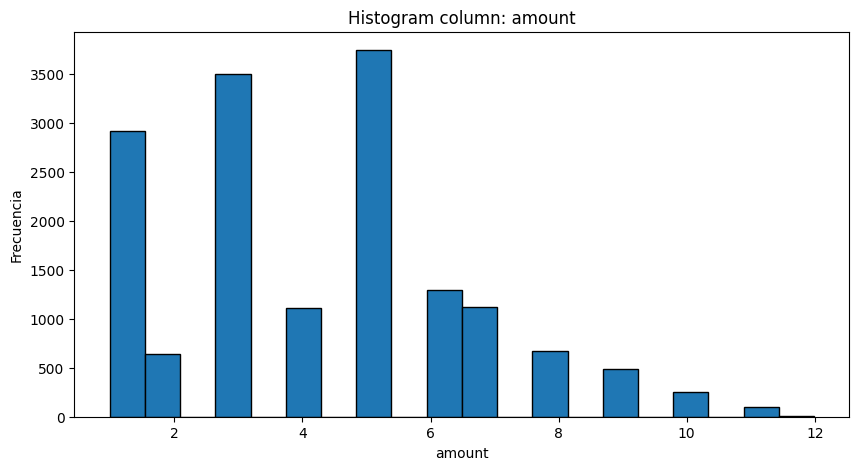

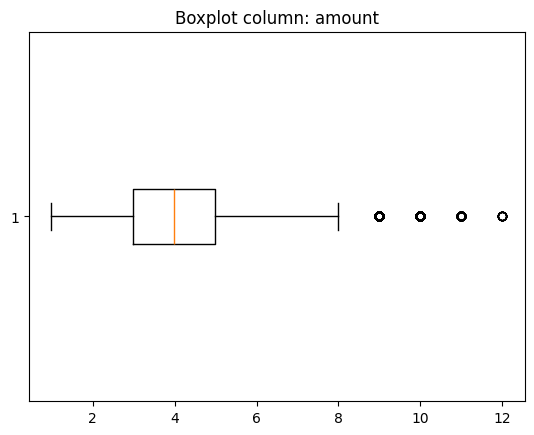

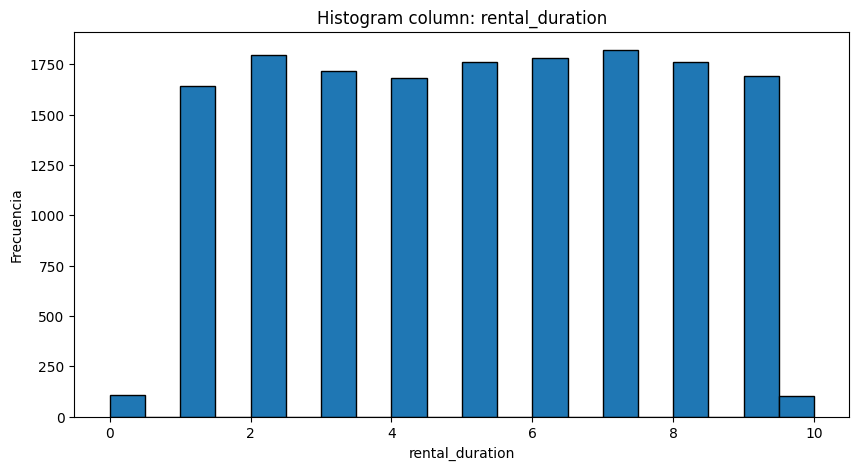

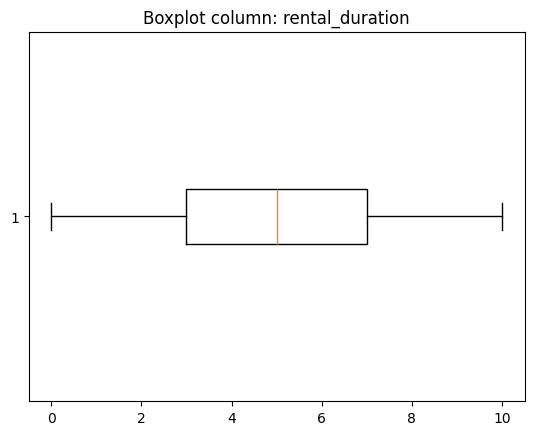

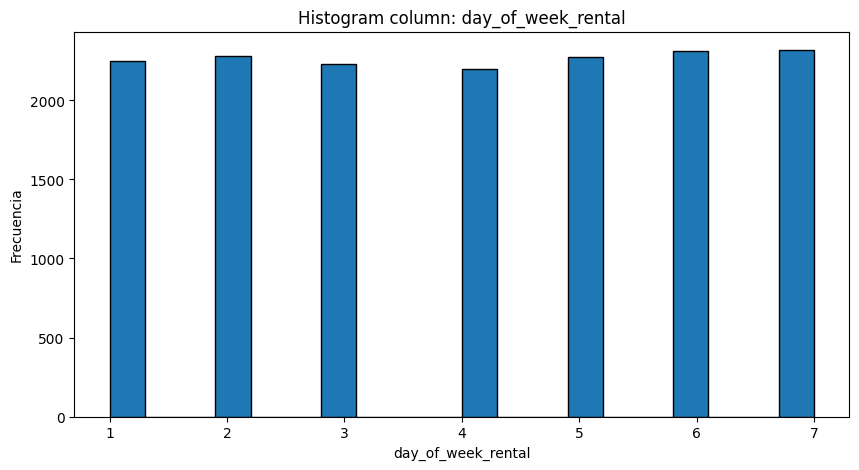

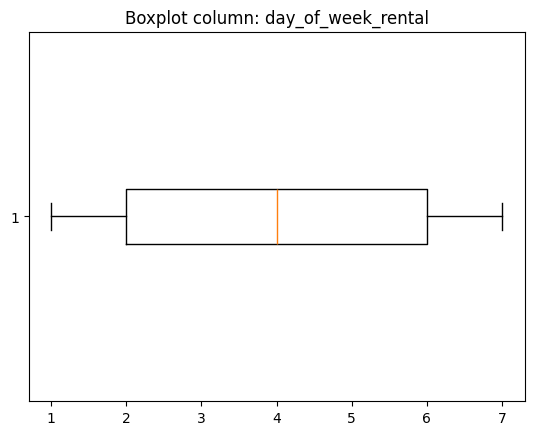

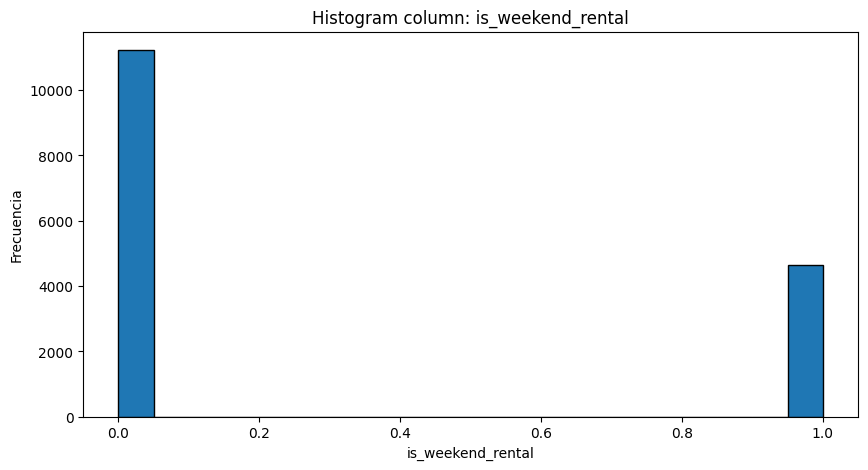

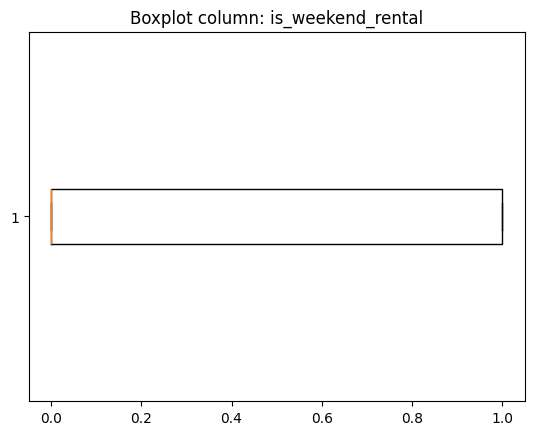

In [23]:
# Visualización mediante un histograma de como se reparten los valores de cada columna 
# y su posterior boxplot para la visualización de outliers
for column in lista_variables_numericas:
    plt.figure(figsize=(10, 5))
    plt.hist(df[column], bins=20, edgecolor='black')
    plt.title(f'Histogram column: {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.show()

    plt.boxplot(df[column], orientation='horizontal')
    plt.title(f'Boxplot column: {column}')
    plt.show()

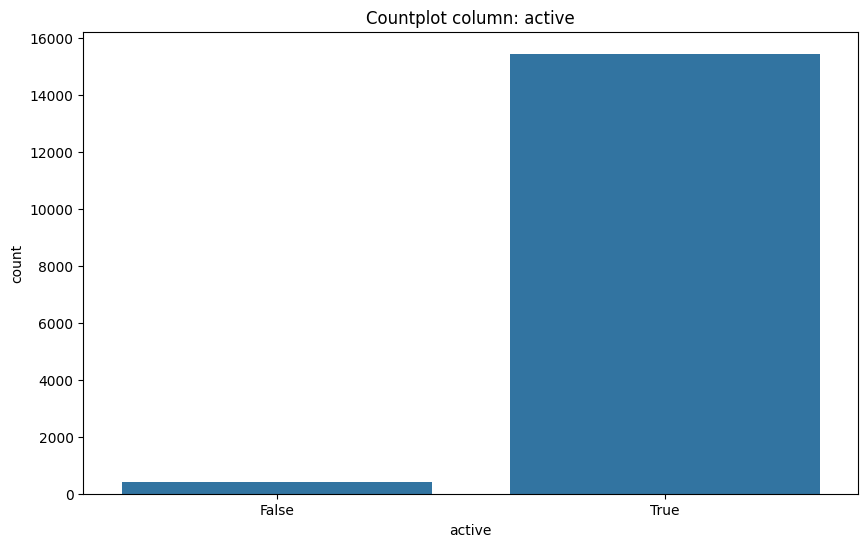

In [24]:
for columna in lista_variables_booleanas:
    plt.figure(figsize=(10,6))
    sns.countplot(data=df, x=columna)
    plt.title(f'Countplot column: {columna}')
    plt.show()

En este caso, solamente poseemos valores outliers en la columna amount, pero al tratarse de solamente 4 valores hemos decidido no realizar ningún tratamiento.

## Dashboard

### Alquileres por día y temporada

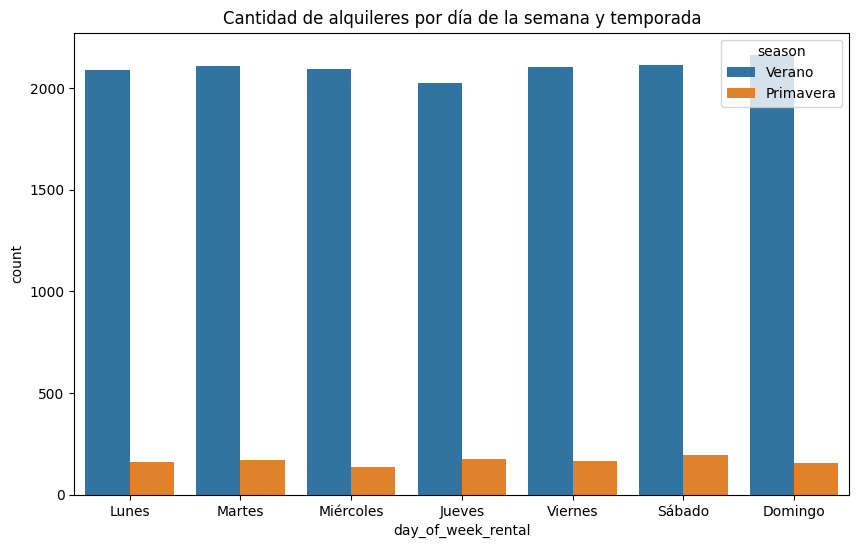

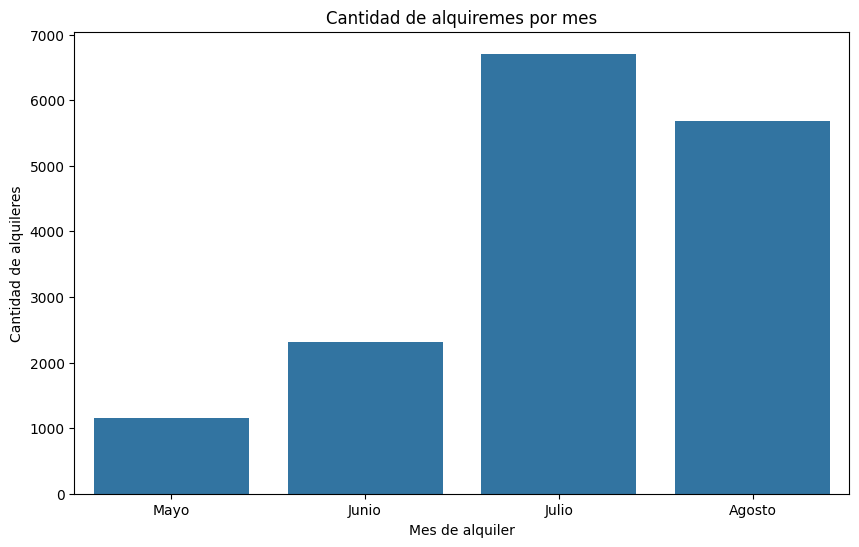

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='day_of_week_rental', hue='season')
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'])
plt.title('Cantidad de alquileres por día de la semana y temporada')
plt.show()
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rental_month')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Mayo', 'Junio', 'Julio', 'Agosto'])
plt.xlabel('Mes de alquiler')
plt.ylabel('Cantidad de alquileres')
plt.title(f'Cantidad de alquiremes por mes')
plt.show()

### Histograma por año

In [26]:
df_filtrado = df[df['rental_year'] != 2005]
conteo = len(df_filtrado)
print(conteo)

0


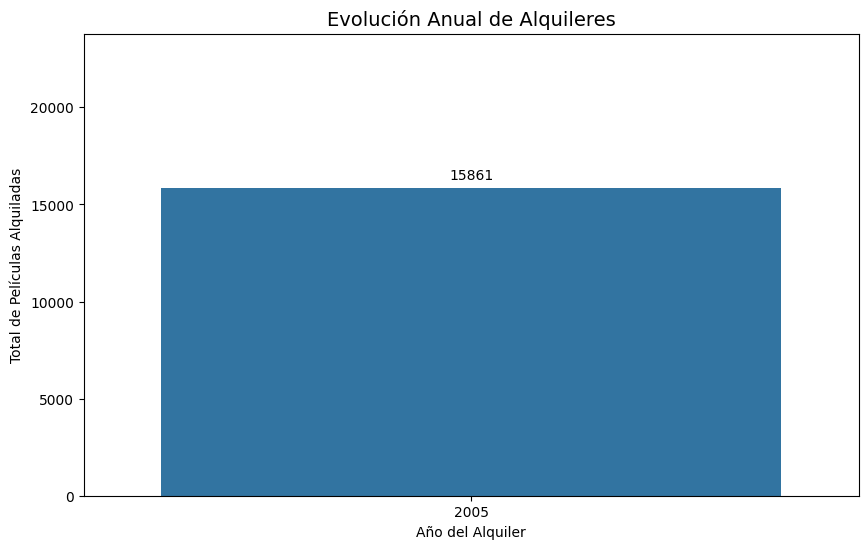

In [27]:
plt.figure(figsize=(10, 6))

# Usamos el año de alquiler en el eje X
sns.countplot(data=df, x='rental_year')

# Añadimos etiquetas 
plt.title('Evolución Anual de Alquileres', fontsize=14)
plt.xlabel('Año del Alquiler')
plt.ylabel('Total de Películas Alquiladas')

# Añadimos el número exacto encima de cada barra para mayor claridad
ax = plt.gca()

max_height = df['rental_year'].value_counts().max()
ax.set_ylim(0, max_height * 1.5)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.show()


### Histograma por horas del día 

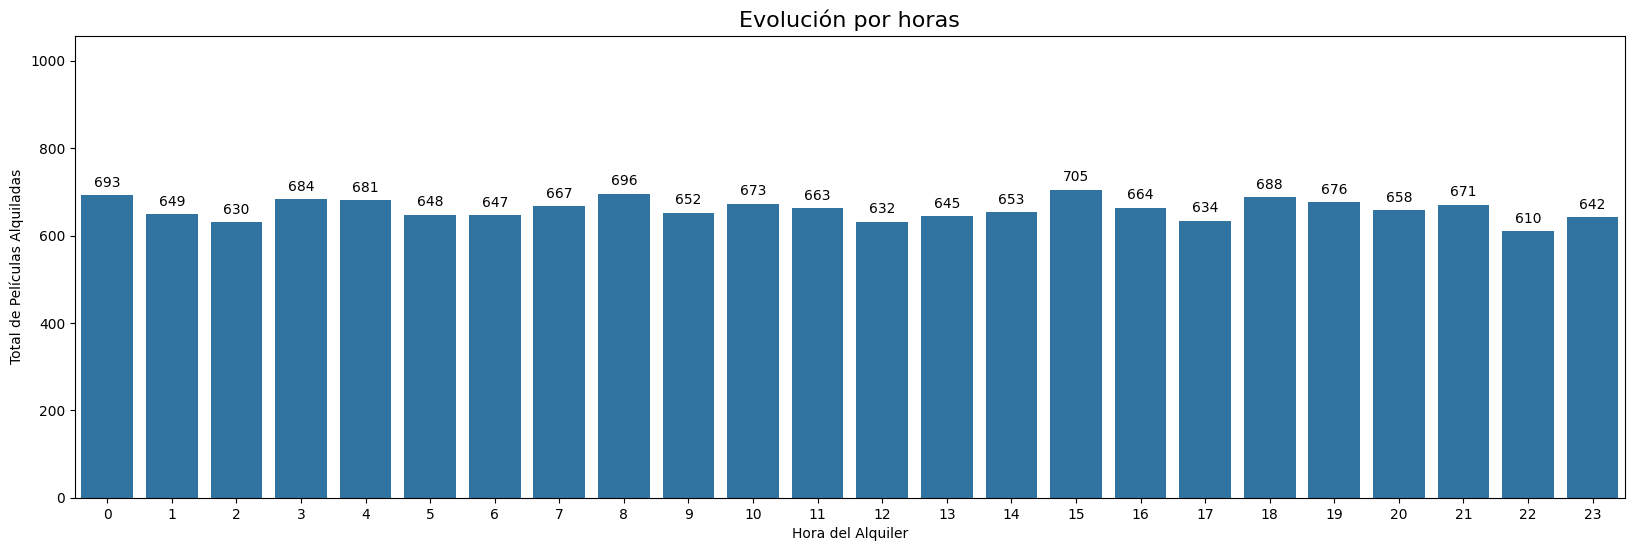

In [28]:
plt.figure(figsize=(20, 6))

# Usamos la hora de alquiler en el eje X
sns.countplot(data=df, x='rental_hour')

# Añadimos etiquetas 
plt.title('Evolución por horas', fontsize=16)
plt.xlabel('Hora del Alquiler')
plt.ylabel('Total de Películas Alquiladas')

# Modificar la altura de y para que quede mas estético
ax = plt.gca()
max_height = df['rental_hour'].value_counts().max()
ax.set_ylim(0, max_height * 1.5)

# Añadimos el número exacto encima de cada barra para mayor claridad

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
    
plt.show()

### Usuarios que mas alquilan

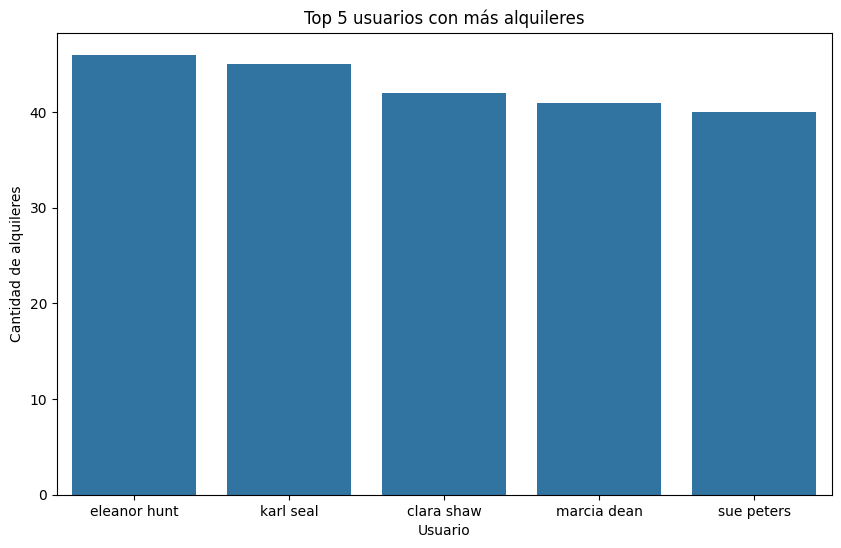

In [29]:
df_top_5_user = df['full_name'].value_counts().head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=df_top_5_user.index, y=df_top_5_user.values)
plt.xlabel('Usuario')
plt.ylabel('Cantidad de alquileres')
plt.title('Top 5 usuarios con más alquileres')
plt.show()